In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.optimizers import Nadam
from keras.metrics import Precision, Recall
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D, GlobalMaxPooling2D, Add, Activation, Multiply, Concatenate, Conv2D
from tensorflow.keras.applications import MobileNetV2

In [2]:
img_size = (224, 224)
batch_size = 32
train_dir = 'D:\\AI\\AI_Project\\CV\\data\\train'
test_dir = 'D:\\AI\\AI_Project\\CV\\data\\test'

train_dg = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,         
    width_shift_range=0.15, 
    height_shift_range=0.15,
    shear_range=0.15, 
    zoom_range=0.05,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3], 
    channel_shift_range=50,
    fill_mode='nearest',
    validation_split=0.2 
)

test_dg = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_dg.flow_from_directory(
    train_dir,
    target_size=img_size,
    color_mode='rgb',
    class_mode="categorical",
    shuffle=True,
    batch_size=batch_size,
    subset='training'  
)

validation_generator = train_dg.flow_from_directory(
    train_dir,
    target_size=img_size,
    color_mode='rgb',
    class_mode="categorical",
    shuffle=False,
    batch_size=batch_size,
    subset='validation' 
)

test_generator = test_dg.flow_from_directory(
    test_dir,
    target_size=img_size,
    class_mode="categorical",
    color_mode="rgb",
    shuffle=False,
    batch_size=batch_size
)

Found 928 images belonging to 6 classes.
Found 230 images belonging to 6 classes.
Found 131 images belonging to 6 classes.


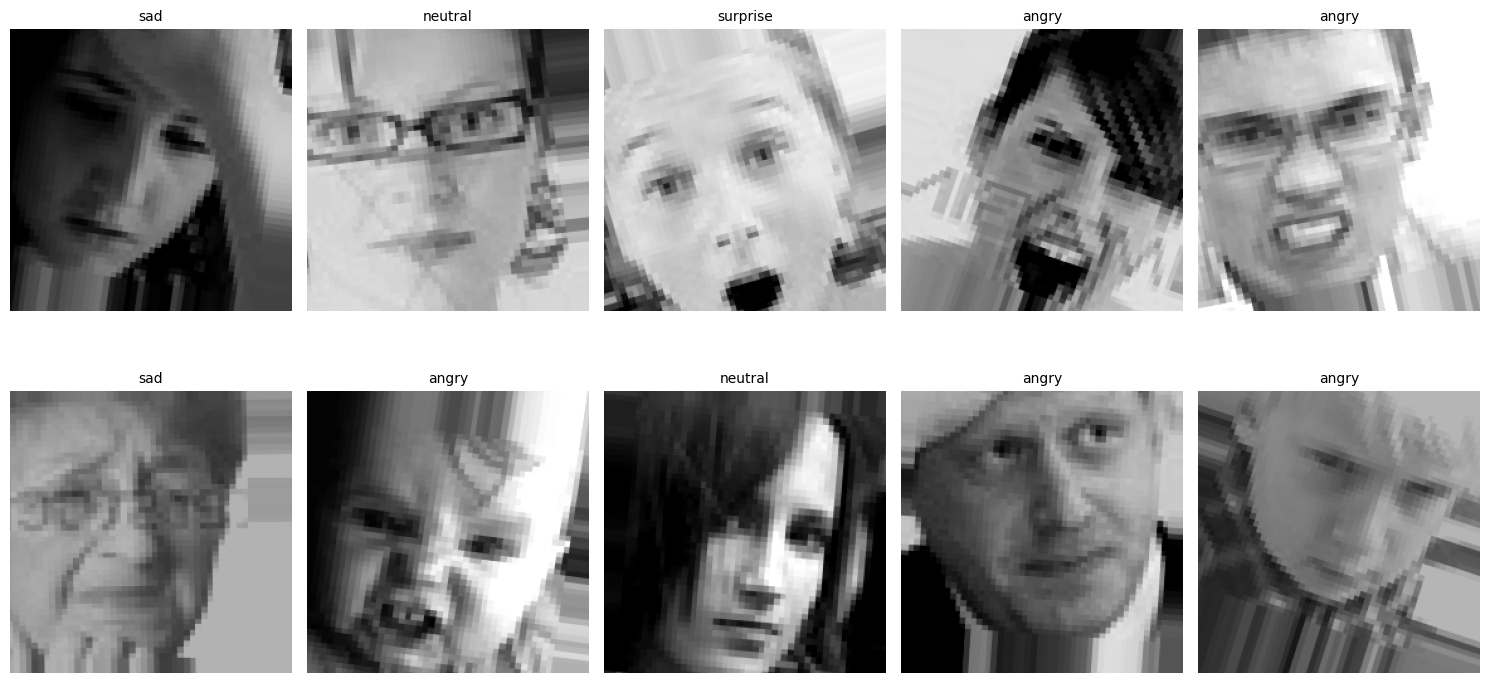

In [3]:
class_names = list(train_generator.class_indices.keys())

def show_samples_grid(generator):
    images, labels = next(generator)
    fig = plt.figure(figsize=(15, 8))
    for i in range(10):
        ax = plt.subplot2grid((2, 5), (i//5, i%5))
        img = ((images[i] + 1) * 127.5).astype(np.uint8)
        ax.imshow(img)
        ax.set_title(class_names[np.argmax(labels[i])], fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_samples_grid(train_generator)

In [4]:
input_shape = (img_size[0], img_size[1], 3)
num_classes = train_generator.num_classes

base_model = MobileNetV2(
    input_shape=input_shape,
    include_top=False,
    weights='imagenet'
)

base_model.summary()

Model: "mobilenetv2_1.00_224"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 112, 112, 32  864         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 112, 112, 32  128         ['Conv1[0][0]']                  
                                )                                              

In [5]:
# Count layers
num_layers = len(base_model.layers)
print("Number of layers:", num_layers)

Number of layers: 154


In [6]:
base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False

In [7]:
from tensorflow.keras import regularizers
from tensorflow.keras.models import Model

def emotion_model():
    """Model đơn giản - ổn định cho 928 ảnh"""
    inputs = base_model.input
    x = base_model.output
    
    x = GlobalAveragePooling2D()(x)
    
    x = Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.6)(x)
    
    x = Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    
    outputs = Dense(6, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    return model

In [8]:
model = emotion_model()

In [9]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 112, 112, 32  864         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 112, 112, 32  128         ['Conv1[0][0]']                  
                                )                                                             

In [10]:
precision = Precision()
recall = Recall()

In [ ]:
model.compile(
    optimizer=Nadam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy', precision, recall]
)

In [12]:
import math
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

checkpoint_dir = 'D:\\AI\\AI_Project\\CV\\checkpoints\\model13'  
os.makedirs(checkpoint_dir, exist_ok=True)

checkpoint_path = os.path.join(checkpoint_dir, 'cp-{epoch:04d}.ckpt')

# ModelCheckpoint
checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1,
    save_weights_only=False
)

# ReduceLROnPlateau
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7, 
    min_lr=1e-8,
    verbose=1,
    cooldown=3  
)

# EarlyStopping - CÓ THỂ TĂNG PATIENCE
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=20,  
    restore_best_weights=True,
    verbose=1,
    mode='max',
    min_delta=0.003
)

# Calculate steps
steps_per_epoch = math.ceil(train_generator.samples / batch_size)
validation_steps = math.ceil(validation_generator.samples / batch_size)

print("Callbacks configured:")
print(f"  Steps per epoch: {steps_per_epoch}")
print(f"  Validation steps: {validation_steps}")
print(f"  Train samples: {train_generator.samples}")
print(f"  Val samples: {validation_generator.samples}")
print(f"  Test samples: {test_generator.samples}")

Callbacks configured:
  Steps per epoch: 29
  Validation steps: 8
  Train samples: 928
  Val samples: 230
  Test samples: 131


In [13]:
history_phase1 = model.fit(
      train_generator,
      validation_data=validation_generator,
      epochs=100,
      batch_size=batch_size,
      callbacks=[checkpoint_callback, reduce_lr, early_stop],
      steps_per_epoch=steps_per_epoch,
      validation_steps=validation_steps,
      verbose=1
  )

Epoch 1/100
29/29 [==============================] - ETA: 0s - loss: 8.8341 - accuracy: 0.2058 - precision: 0.2073 - recall: 0.1401
Epoch 1: val_accuracy improved from -inf to 0.16522, saving model to D:\AI\AI_Project\CV\checkpoints\model13\cp-0001.ckpt


INFO:tensorflow:Assets written to: D:\AI\AI_Project\CV\checkpoints\model13\cp-0001.ckpt\assets


INFO:tensorflow:Assets written to: D:\AI\AI_Project\CV\checkpoints\model13\cp-0001.ckpt\assets


29/29 [==============================] - 69s 2s/step - loss: 8.8341 - accuracy: 0.2058 - precision: 0.2073 - recall: 0.1401 - val_loss: 7.9161 - val_accuracy: 0.1652 - val_precision: 0.2154 - val_recall: 0.0609 - lr: 1.0000e-04
Epoch 2/100
29/29 [==============================] - ETA: 0s - loss: 8.5983 - accuracy: 0.2047 - precision: 0.2195 - recall: 0.1455
Epoch 2: val_accuracy improved from 0.16522 to 0.22174, saving model to D:\AI\AI_Project\CV\checkpoints\model13\cp-0002.ckpt


INFO:tensorflow:Assets written to: D:\AI\AI_Project\CV\checkpoints\model13\cp-0002.ckpt\assets


...

INFO:tensorflow:Assets written to: D:\AI\AI_Project\CV\checkpoints\model13\cp-0033.ckpt\assets


29/29 [==============================] - 22s 761ms/step - loss: 5.8963 - accuracy: 0.7209 - precision: 0.7714 - recall: 0.6692 - val_loss: 6.5485 - val_accuracy: 0.5696 - val_precision: 0.5990 - val_recall: 0.5261 - lr: 1.0000e-04
Epoch 34/100
29/29 [==============================] - ETA: 0s - loss: 5.7799 - accuracy: 0.7435 - precision: 0.7902 - recall: 0.6983
Epoch 34: val_accuracy improved from 0.56957 to 0.59565, saving model to D:\AI\AI_Project\CV\checkpoints\model13\cp-0034.ckpt


INFO:tensorflow:Assets written to: D:\AI\AI_Project\CV\checkpoints\model13\cp-0034.ckpt\assets


INFO:tensorflow:Assets written to: D:\AI\AI_Project\CV\checkpoints\model13\cp-0034.ckpt\assets


29/29 [==============================] - 22s 754ms/step - loss: 5.7799 - accuracy: 0.7435 - precision: 0.7902 - recall: 0.6983 - val_loss: 6.3717 - val_accuracy: 0.5957 - val_precision: 0.6414 - val_recall: 0.5522 - lr: 1.0000e-04
Epoch 35/100
29/29 [==============================] - ETA: 0s - loss: 5.8699 - accuracy: 0.7166 - precision: 0.7596 - recall: 0.6638
Epoch 35: val_accuracy did not improve from 0.59565
29/29 [==============================] - 13s 446ms/step - loss: 5.8699 - accuracy: 0.7166 - precision: 0.7596 - recall: 0.6638 - val_loss: 6.6074 - val_accuracy: 0.5348 - val_precision: 0.5838 - val_recall: 0.5000 - lr: 1.0000e-04
Epoch 36/100
29/29 [==============================] - ETA: 0s - loss: 5.7533 - accuracy: 0.7435 - precision: 0.7849 - recall: 0.7037
Epoch 36: val_accuracy did not improve from 0.59565
29/29 [==============================] - 15s 511ms/step - loss: 5.7533 - accuracy: 0.7435 - precision: 0.7849 - recall: 0.7037 - val_loss: 6.5223 - val_accuracy: 0.5000

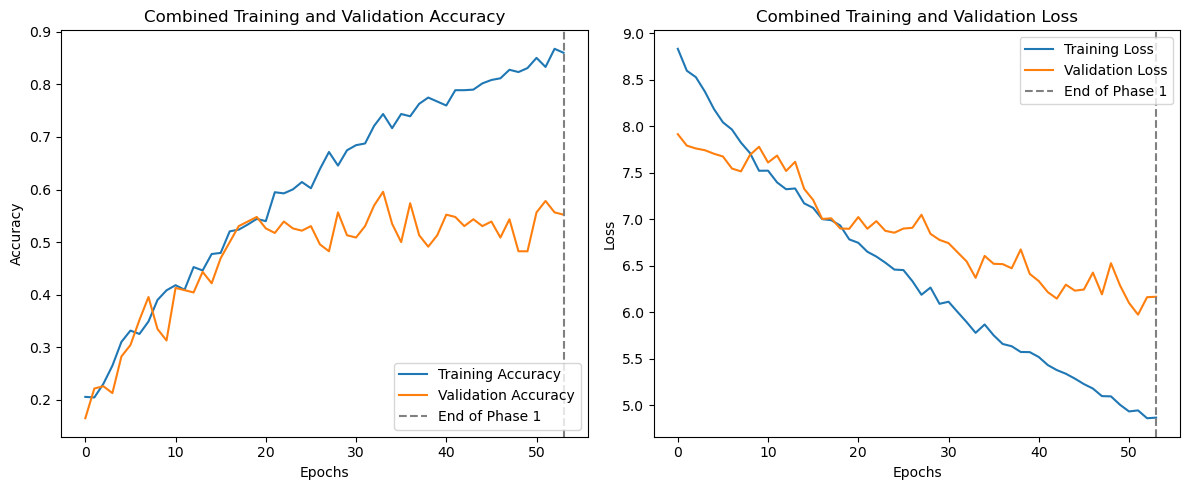

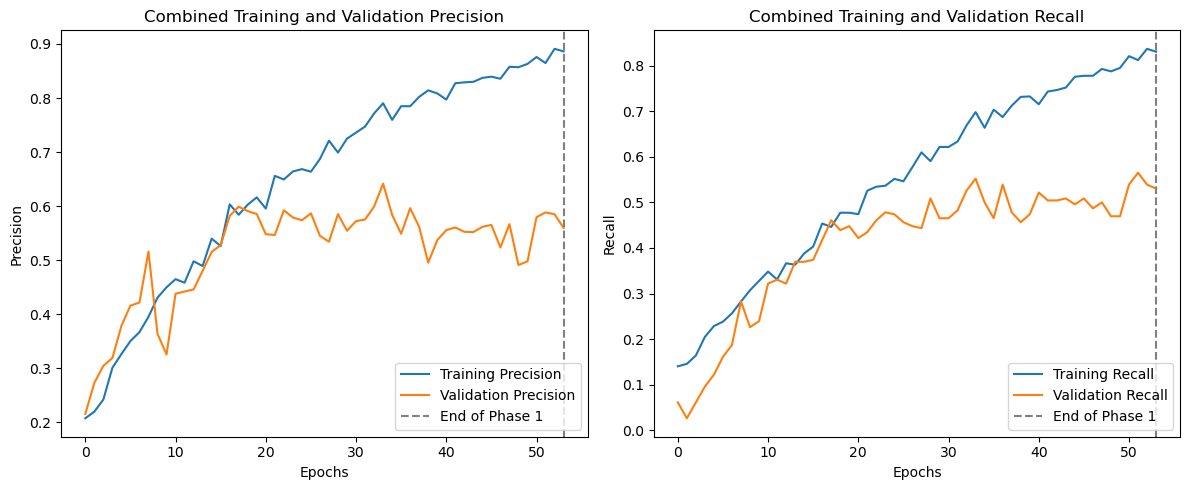

In [14]:
acc = history_phase1.history['accuracy'] 
val_acc = history_phase1.history['val_accuracy'] 
loss = history_phase1.history['loss'] 
val_loss = history_phase1.history['val_loss'] 

# Nếu bạn có các metrics khác như precision, recall
precision_metric = history_phase1.history['precision']
val_precision_metric = history_phase1.history['val_precision'] 
recall_metric = history_phase1.history['recall'] 
val_recall_metric = history_phase1.history['val_recall'] 

# Tạo dải epochs tổng cộng
epochs_range_total = range(len(acc)) # Tổng số epochs đã chạy

# Vẽ đồ thị
plt.figure(figsize=(12, 5))

# Đồ thị Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range_total, acc, label='Training Accuracy')
plt.plot(epochs_range_total, val_acc, label='Validation Accuracy')
# Vẽ đường phân chia giữa 2 giai đoạn
plt.axvline(x=len(history_phase1.history['accuracy']) - 1, color='grey', linestyle='--', label='End of Phase 1')
plt.legend(loc='lower right')
plt.title('Combined Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# Đồ thị Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range_total, loss, label='Training Loss')
plt.plot(epochs_range_total, val_loss, label='Validation Loss')
# Vẽ đường phân chia giữa 2 giai đoạn
plt.axvline(x=len(history_phase1.history['loss']) - 1, color='grey', linestyle='--', label='End of Phase 1')
plt.legend(loc='upper right')
plt.title('Combined Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()

# Đồ thị cho precision và recall 
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range_total, precision_metric, label='Training Precision')
plt.plot(epochs_range_total, val_precision_metric, label='Validation Precision')
plt.axvline(x=len(history_phase1.history['precision']) - 1, color='grey', linestyle='--', label='End of Phase 1')
plt.legend(loc='lower right')
plt.title('Combined Training and Validation Precision')
plt.xlabel('Epochs')
plt.ylabel('Precision')

plt.subplot(1, 2, 2)
plt.plot(epochs_range_total, recall_metric, label='Training Recall')
plt.plot(epochs_range_total, val_recall_metric, label='Validation Recall')
plt.axvline(x=len(history_phase1.history['recall']) - 1, color='grey', linestyle='--', label='End of Phase 1')
plt.legend(loc='lower right')
plt.title('Combined Training and Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
#
plt.tight_layout()
plt.show()

In [15]:
from sklearn.metrics import classification_report, confusion_matrix

# Lấy dự đoán
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# Lấy nhãn thật
y_true = test_generator.classes

# Lấy tên các lớp cảm xúc
class_names = list(test_generator.class_indices.keys())

# In báo cáo
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# In ma trận nhầm lẫn
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

5/5 [==============================] - 4s 569ms/step
Classification Report:
              precision    recall  f1-score   support

       angry       0.55      1.00      0.71        22
        fear       1.00      0.48      0.65        21
       happy       0.84      0.73      0.78        22
     neutral       0.79      0.50      0.61        22
         sad       0.53      0.73      0.62        22
    surprise       0.67      0.55      0.60        22

    accuracy                           0.66       131
   macro avg       0.73      0.66      0.66       131
weighted avg       0.73      0.66      0.66       131

Confusion Matrix:
[[22  0  0  0  0  0]
 [ 3 10  2  0  1  5]
 [ 3  0 16  0  2  1]
 [ 4  0  1 11  6  0]
 [ 5  0  0  1 16  0]
 [ 3  0  0  2  5 12]]


In [16]:
# Lưu model thành file .h5 sau khi huấn luyện
model.save('emotion_model.h5')
print('Model đã được lưu thành công: emotion_model.h5')

Model đã được lưu thành công: emotion_model.h5
